# Assignment 7: Neural Network (ANN) Implementation — Shallow vs Deep
**Student ID:** 220133

This notebook implements, tunes, and compares two distinct **Neural Network** architectures:

* **Shallow Neural Network** — exactly one hidden layer
* **Deep Neural Network** — at least three hidden layers with regularization

Both models are built with **PyTorch** and trained on the **AI Student Impact Dataset**
to predict the multi-class target `Burnout_Risk_Level` (Low / Medium / High).

## Dataset
* **Source:** AI Student Impact Dataset (Kaggle)
* **Target:** `Burnout_Risk_Level` (multi-class: Low, Medium, High)
* **Size:** 50,000 samples, 16 columns, no missing values

## Pipeline
1. Load data automatically from GitHub raw URL.
2. Exploratory data analysis (EDA).
3. Preprocessing: encode categoricals, stratified split, scale features.
4. Build and tune a **Shallow NN** (1 hidden layer).
5. Build and tune a **Deep NN** (3+ hidden layers with dropout).
6. Generate 2×1 side-by-side comparison visualisations.
7. Critical analysis contrasting the two architectures.

## 0. Imports and Configuration

In [1]:
import os, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SCREENSHOT_DIR = 'screenshots'
os.makedirs(SCREENSHOT_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})
sns.set_style('whitegrid')
print('Environment ready.')

Device: cpu
Environment ready.


## 1. Load Dataset

In [2]:
local_path = 'ai_student_impact_dataset.csv'
remote_url = (
    'https://raw.githubusercontent.com/ahsanjust/'
    'Artificial-Intelligence-and-Machine-Learning-Lab/master/'
    'Lab_5_v2/ai_student_impact_dataset.csv'
)

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f'Loaded from local: {local_path}')
else:
    df = pd.read_csv(remote_url)
    print(f'Loaded from GitHub: {remote_url}')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Loaded from local: ai_student_impact_dataset.csv
Shape: (50000, 16)
Columns: ['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']


## 2. Exploratory Data Analysis

In [3]:
display(df.head())
print('\nDataset info:')
df.info()
print('\nStatistical summary:')
display(df.describe(include='all').T)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA          

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,50000.0,NaN,NaN,NaN,125000.5,14433.901067,100001.0,112500.75,125000.5,137500.25,150000.0
Major_Category,50000,5,STEM,15059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Study,50000,5,Junior,11045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pre_Semester_GPA,50000.0,NaN,NaN,NaN,3.146102,0.478854,1.183,2.834,3.21,3.521,3.998
Weekly_GenAI_Hours,50000.0,NaN,NaN,NaN,8.427752,8.26949,0.0,2.39,5.8,11.72,40.0
Primary_Use_Case,50000,5,Debugging/Troubleshooting,12295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Prompt_Engineering_Skill,50000,3,Beginner,18495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tool_Diversity,50000.0,NaN,NaN,NaN,2.80026,1.18802,1.0,2.0,3.0,4.0,5.0
Paid_Subscription,50000,2,False,28846,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traditional_Study_Hours,50000.0,NaN,NaN,NaN,11.209271,5.156426,1.0,7.56,11.18,14.71,35.86


Class distribution:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


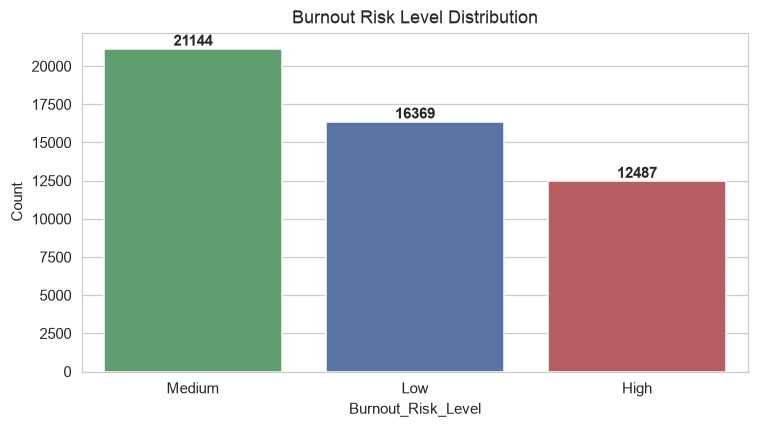

In [4]:
class_counts = df['Burnout_Risk_Level'].value_counts()
print('Class distribution:')
print(class_counts)

plt.figure(figsize=(7, 4))
palette = {'Low': '#4C72B0', 'Medium': '#55A868', 'High': '#C44E52'}
sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette)
plt.ylabel('Count')
plt.title('Burnout Risk Level Distribution')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Class_Distribution.png'), bbox_inches='tight')
plt.show()

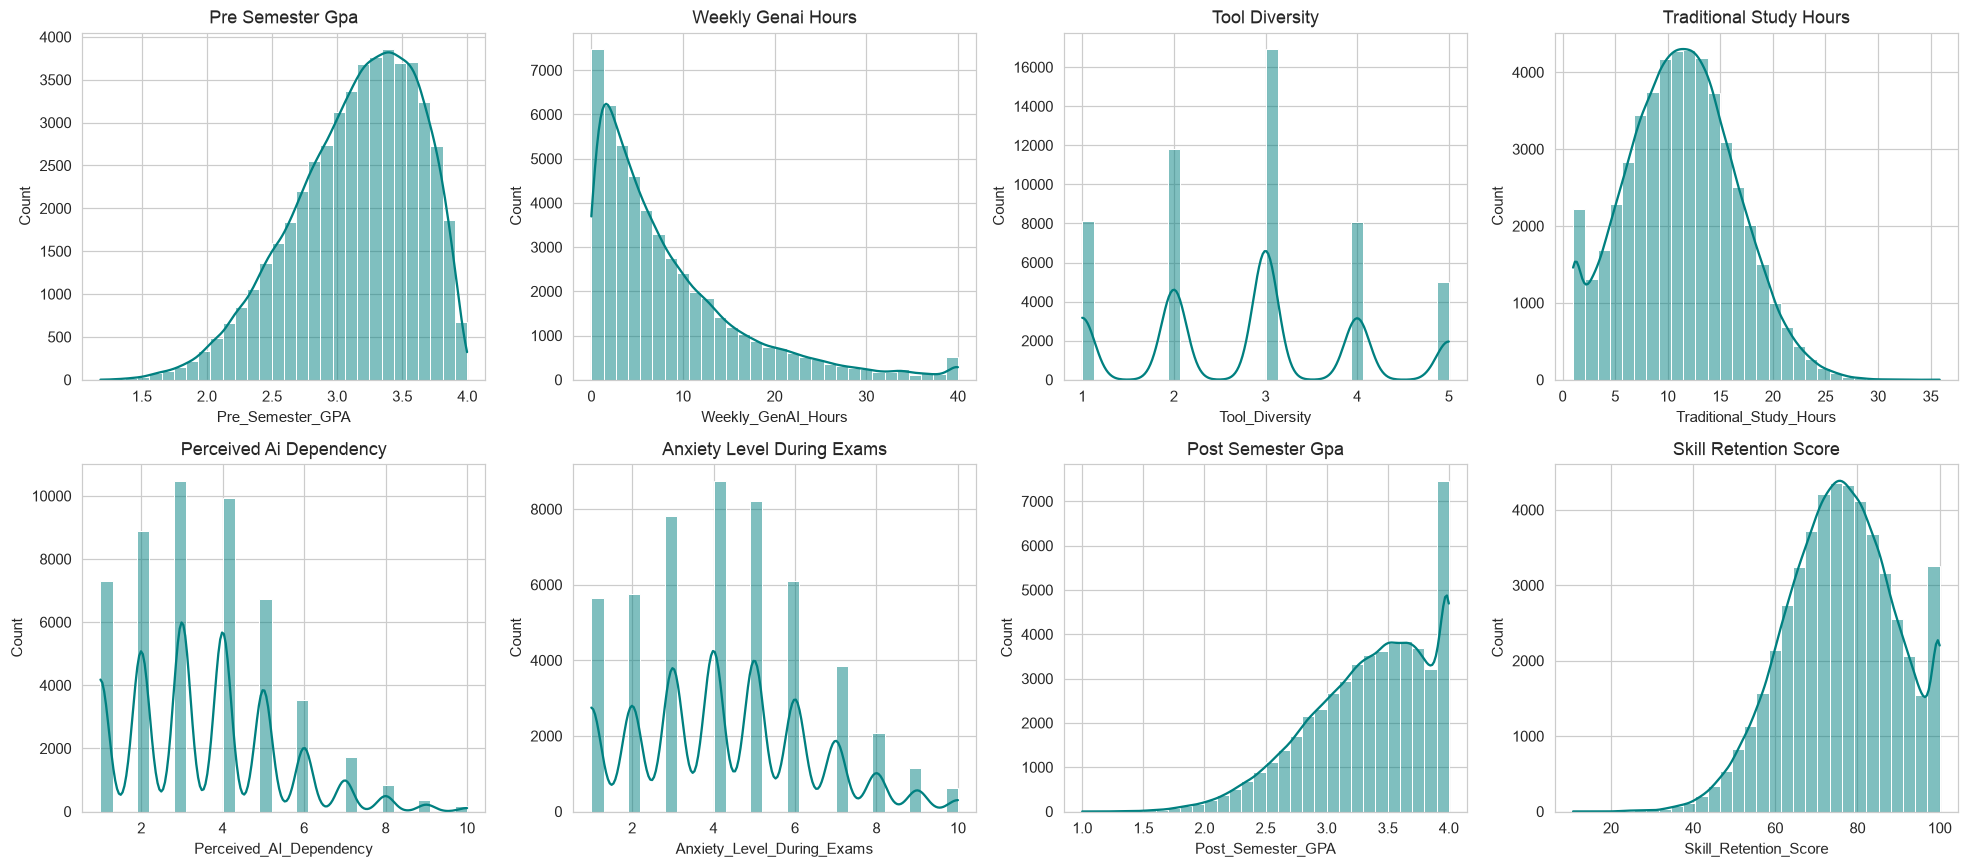

In [5]:
num_features = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
                'Traditional_Study_Hours', 'Perceived_AI_Dependency',
                'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, feat in enumerate(num_features):
    sns.histplot(df[feat], bins=30, kde=True, ax=axes.flat[i], color='teal')
    axes.flat[i].set_title(feat.replace('_', ' ').title())
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Feature_Distributions.png'), bbox_inches='tight')
plt.show()

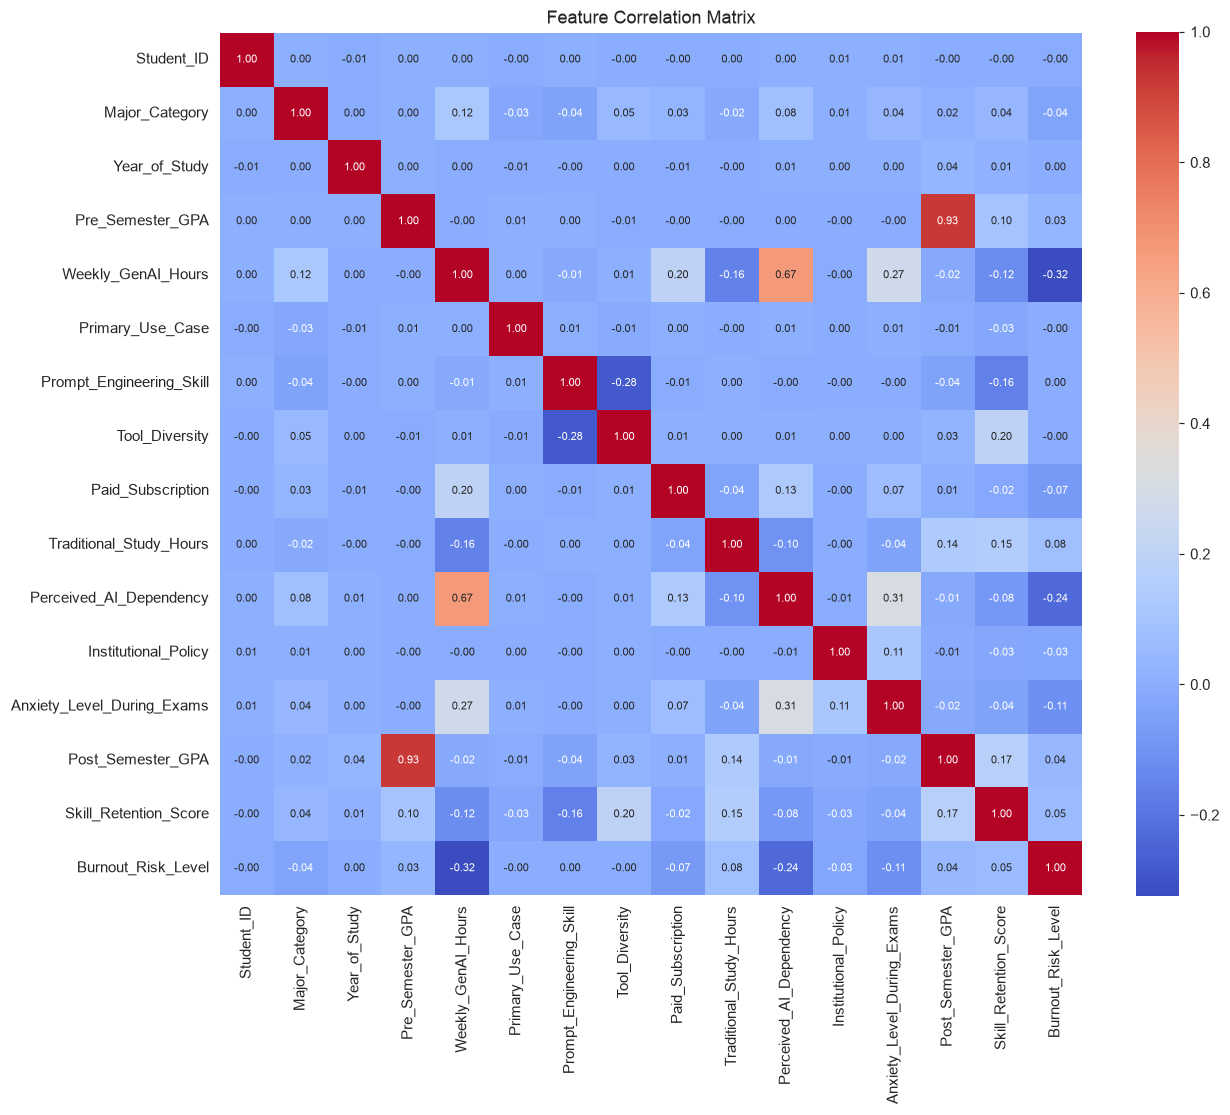


Top features correlated with Burnout_Risk_Level:
Traditional_Study_Hours       0.076333
Skill_Retention_Score         0.053905
Post_Semester_GPA             0.043435
Pre_Semester_GPA              0.032731
Prompt_Engineering_Skill      0.001327
Year_of_Study                 0.000801
Primary_Use_Case             -0.000652
Tool_Diversity               -0.002811
Student_ID                   -0.003761
Institutional_Policy         -0.031917
Major_Category               -0.037937
Paid_Subscription            -0.071081
Anxiety_Level_During_Exams   -0.114558
Perceived_AI_Dependency      -0.235125
Weekly_GenAI_Hours           -0.324500
Name: Burnout_Risk_Level, dtype: float64


In [6]:
df_corr = df.copy()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Correlation_Heatmap.png'), bbox_inches='tight')
plt.show()

target_corr = df_corr.corr()['Burnout_Risk_Level'].drop('Burnout_Risk_Level').sort_values(ascending=False)
print('\nTop features correlated with Burnout_Risk_Level:')
print(target_corr)

## 3. Data Preprocessing

In [7]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

Total missing values: 0


In [8]:
df_encoded = df.copy()
label_encoders = {}

feature_cat_cols = [c for c in df_encoded.select_dtypes(include='object').columns if c != 'Burnout_Risk_Level']
for col in feature_cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

target_le = LabelEncoder()
df_encoded['Burnout_Risk_Level'] = target_le.fit_transform(df_encoded['Burnout_Risk_Level'])

print('Encoding maps:')
for col, le in label_encoders.items():
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'  Burnout_Risk_Level: {dict(zip(target_le.classes_, target_le.transform(target_le.classes_)))}')

Encoding maps:
  Major_Category: {'Arts': 0, 'Business': 1, 'Humanities': 2, 'Medical': 3, 'STEM': 4}
  Year_of_Study: {'Freshman': 0, 'Graduate': 1, 'Junior': 2, 'Senior': 3, 'Sophomore': 4}
  Primary_Use_Case: {'Copywriting/Drafting': 0, 'Debugging/Troubleshooting': 1, 'Direct_Answer_Generation': 2, 'Ideation': 3, 'Summarizing_Reading': 4}
  Prompt_Engineering_Skill: {'Advanced': 0, 'Beginner': 1, 'Intermediate': 2}
  Institutional_Policy: {'Actively_Encouraged': 0, 'Allowed_With_Citation': 1, 'Strict_Ban': 2}
  Burnout_Risk_Level: {'High': 0, 'Low': 1, 'Medium': 2}


In [9]:
X = df_encoded.drop('Burnout_Risk_Level', axis=1)
y = df_encoded['Burnout_Risk_Level']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

n_classes = len(target_le.classes_)
n_features = X_train.shape[1]
print(f'Classes: {list(target_le.classes_)} ({n_classes} classes)')
print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'Features: {n_features}')

Classes: ['High', 'Low', 'Medium'] (3 classes)
Train: 35000 | Val: 7500 | Test: 7500
Features: 15


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print(f'Scaling done. Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}')

Scaling done. Train mean: -0.000000, std: 1.000000


In [11]:
def to_tensor(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y.values, dtype=torch.long).to(DEVICE)
    return X_t, y_t

X_train_t, y_train_t = to_tensor(X_train_scaled, y_train)
X_val_t, y_val_t = to_tensor(X_val_scaled, y_val)
X_test_t, y_test_t = to_tensor(X_test_scaled, y_test)

print(f'Tensors ready. X_train: {X_train_t.shape}, y_train: {y_train_t.shape}')

Tensors ready. X_train: torch.Size([35000, 15]), y_train: torch.Size([35000])


## 4. Training and Evaluation Utilities

In [12]:
class_counts_train = torch.bincount(y_train_t, minlength=n_classes).float()
class_weights = y_train_t.shape[0] / (n_classes * class_counts_train)
class_weights[torch.isinf(class_weights)] = 1.0
print(f'Class weights: {class_weights.tolist()}')

def train_model(model, criterion, optimizer, X_tr, y_tr, X_v, y_v,
                epochs=50, batch_size=128, verbose=False):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    dataset = TensorDataset(X_tr, y_tr)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)

        history['train_loss'].append(total_loss / total)
        history['train_acc'].append(correct / total)

        model.eval()
        with torch.no_grad():
            vl = criterion(model(X_v), y_v).item()
            va = (model(X_v).argmax(1) == y_v).float().mean().item()
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if verbose and epoch % 25 == 0:
            print(f'  Ep {epoch:3d} | Train Loss: {history["train_loss"][-1]:.4f} '
                  f'Val Loss: {vl:.4f} | Train Acc: {history["train_acc"][-1]:.4f} Val Acc: {va:.4f}')
    return history

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(X), dim=1).cpu().numpy()
    y_true = y.cpu().numpy().flatten()
    y_pred = probs.argmax(axis=1)
    return {
        'y_true': y_true, 'y_pred': y_pred, 'y_prob': probs,
        'acc': accuracy_score(y_true, y_pred),
        'prec': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'rec': recall_score(y_true, y_pred, average='weighted'),
        'f1': f1_score(y_true, y_pred, average='weighted'),
        'auc': roc_auc_score(y_true, probs, multi_class='ovr', average='weighted'),
    }

Class weights: [1.33470618724823, 1.0182114839553833, 0.7882350087165833]


## 5. Shallow Neural Network

Exactly one hidden layer. Tuned on: hidden units, activation, batch size.
We subsample 10K training points for fast hyperparameter search.

In [13]:
# Subsample for fast tuning (10K samples)
TUNE_N = 3000
idx = torch.randperm(len(X_train_t))[:TUNE_N]
X_tune, y_tune = X_train_t[idx], y_train_t[idx]
print(f'Tuning subset: {X_tune.shape[0]} samples (from {len(X_train_t)})')

Tuning subset: 3000 samples (from 35000)


In [14]:
class ShallowNN(nn.Module):
    def __init__(self, in_dim, hid=64, n_cls=3, act='relu'):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid),
            nn.ReLU() if act == 'relu' else nn.Tanh() if act == 'tanh' else nn.Sigmoid(),
            nn.Linear(hid, n_cls)
        )
    def forward(self, x):
        return self.net(x)

In [15]:
best_sf, best_sc = 0.0, None
shallow_history_best = None
shallow_configs = []

for hid in [32, 64, 128]:
    for act in ['relu', 'tanh']:
        for bs in [64, 128]:
            m = ShallowNN(n_features, hid, n_classes, act).to(DEVICE)
            crit = nn.CrossEntropyLoss(weight=class_weights)
            opt = optim.Adam(m.parameters(), lr=0.001)
            h = train_model(m, crit, opt, X_tune, y_tune, X_val_t, y_val_t, epochs=15, batch_size=bs)
            met = evaluate_model(m, X_val_t, y_val_t)
            shallow_configs.append({'hid': hid, 'act': act, 'bs': bs, 'f1': met['f1'], 'auc': met['auc']})
            if met['f1'] > best_sf:
                best_sf, best_sc, shallow_history_best = met['f1'], {'hid': hid, 'act': act, 'bs': bs}, h
            print(f'  hid={hid:3d} act={act:5s} bs={bs:3d} -> F1={met["f1"]:.4f} AUC={met["auc"]:.4f}')

print(f'\nBest Shallow: {best_sc} | Val F1={best_sf:.4f}')

  hid= 32 act=relu  bs= 64 -> F1=0.4724 AUC=0.6628


  hid= 32 act=relu  bs=128 -> F1=0.4693 AUC=0.6626


  hid= 32 act=tanh  bs= 64 -> F1=0.4718 AUC=0.6655


  hid= 32 act=tanh  bs=128 -> F1=0.4665 AUC=0.6640


  hid= 64 act=relu  bs= 64 -> F1=0.4761 AUC=0.6643


...

  hid= 64 act=tanh  bs=128 -> F1=0.4738 AUC=0.6680


  hid=128 act=relu  bs= 64 -> F1=0.4662 AUC=0.6622


  hid=128 act=relu  bs=128 -> F1=0.4699 AUC=0.6660


  hid=128 act=tanh  bs= 64 -> F1=0.4751 AUC=0.6645


  hid=128 act=tanh  bs=128 -> F1=0.4736 AUC=0.6678

Best Shallow: {'hid': 64, 'act': 'relu', 'bs': 64} | Val F1=0.4761


In [16]:
X_comb = torch.cat([X_train_t, X_val_t])
y_comb = torch.cat([y_train_t, y_val_t])

final_shallow = ShallowNN(n_features, best_sc['hid'], n_classes, best_sc['act']).to(DEVICE)
criterion_s = nn.CrossEntropyLoss(weight=class_weights)
optimizer_s = optim.Adam(final_shallow.parameters(), lr=0.001)

print('Training final Shallow NN on combined train+val...')
shallow_hist_final = train_model(final_shallow, criterion_s, optimizer_s,
    X_comb, y_comb, X_test_t, y_test_t, epochs=20, batch_size=best_sc['bs'], verbose=True)
print('Done.')

Training final Shallow NN on combined train+val...


Done.


## 6. Deep Neural Network

At least 3 hidden layers with Dropout + BatchNorm + L2 regularization.
Tuned on: learning rate, optimizer.

In [17]:
class DeepNN(nn.Module):
    def __init__(self, in_dim, hids=[128, 64, 32], n_cls=3, drop=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hids:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(drop)]
            prev = h
        layers.append(nn.Linear(prev, n_cls))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

In [18]:
best_df, best_dc = 0.0, None
deep_history_best = None
deep_configs = []

for lr in [0.01, 0.001, 0.0001]:
    for opt_name in ['adam', 'sgd']:
        m = DeepNN(n_features, [128, 64, 32], n_classes).to(DEVICE)
        crit = nn.CrossEntropyLoss(weight=class_weights)
        opt = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4) if opt_name == 'adam' \
            else optim.SGD(m.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
        h = train_model(m, crit, opt, X_tune, y_tune, X_val_t, y_val_t, epochs=15, batch_size=128)
        met = evaluate_model(m, X_val_t, y_val_t)
        deep_configs.append({'lr': lr, 'opt': opt_name, 'f1': met['f1'], 'auc': met['auc']})
        if met['f1'] > best_df:
            best_df, best_dc, deep_history_best = met['f1'], {'lr': lr, 'opt': opt_name}, h
        print(f'  lr={lr:.4f} opt={opt_name:5s} -> F1={met["f1"]:.4f} AUC={met["auc"]:.4f}')

print(f'\nBest Deep: {best_dc} | Val F1={best_df:.4f}')

  lr=0.0100 opt=adam  -> F1=0.4689 AUC=0.6529


  lr=0.0100 opt=sgd   -> F1=0.4424 AUC=0.6622


  lr=0.0010 opt=adam  -> F1=0.4485 AUC=0.6635


  lr=0.0010 opt=sgd   -> F1=0.4382 AUC=0.6443


  lr=0.0001 opt=adam  -> F1=0.3526 AUC=0.6466


  lr=0.0001 opt=sgd   -> F1=0.2877 AUC=0.5775

Best Deep: {'lr': 0.01, 'opt': 'adam'} | Val F1=0.4689


In [19]:
final_deep = DeepNN(n_features, [128, 64, 32], n_classes).to(DEVICE)
criterion_d = nn.CrossEntropyLoss(weight=class_weights)
optimizer_d = optim.Adam(final_deep.parameters(), lr=best_dc['lr'], weight_decay=1e-4) \
    if best_dc['opt'] == 'adam' \
    else optim.SGD(final_deep.parameters(), lr=best_dc['lr'], momentum=0.9, weight_decay=1e-4)

print('Training final Deep NN on combined train+val...')
deep_hist_final = train_model(final_deep, criterion_d, optimizer_d,
    X_comb, y_comb, X_test_t, y_test_t, epochs=20, batch_size=128, verbose=True)
print('Done.')

Training final Deep NN on combined train+val...


Done.


## 7. Test-Set Evaluation

In [20]:
shallow_met = evaluate_model(final_shallow, X_test_t, y_test_t)
deep_met = evaluate_model(final_deep, X_test_t, y_test_t)

for name, m in [('Shallow NN', shallow_met), ('Deep NN', deep_met)]:
    print(f'\n=== {name} ===')
    print(f'  Accuracy:  {m["acc"]:.4f}')
    print(f'  Precision: {m["prec"]:.4f} (weighted)')
    print(f'  Recall:    {m["rec"]:.4f} (weighted)')
    print(f'  F1-Score:  {m["f1"]:.4f} (weighted)')
    print(f'  AUC-ROC:   {m["auc"]:.4f} (weighted OvR)')


=== Shallow NN ===
  Accuracy:  0.5047
  Precision: 0.5075 (weighted)
  Recall:    0.5047 (weighted)
  F1-Score:  0.4798 (weighted)
  AUC-ROC:   0.6909 (weighted OvR)

=== Deep NN ===
  Accuracy:  0.5085
  Precision: 0.5072 (weighted)
  Recall:    0.5085 (weighted)
  F1-Score:  0.4952 (weighted)
  AUC-ROC:   0.6823 (weighted OvR)


## 8. Required Visualisations — 2×1 Comparison Matrix

### 8.1 Training History — Loss and Accuracy Curves

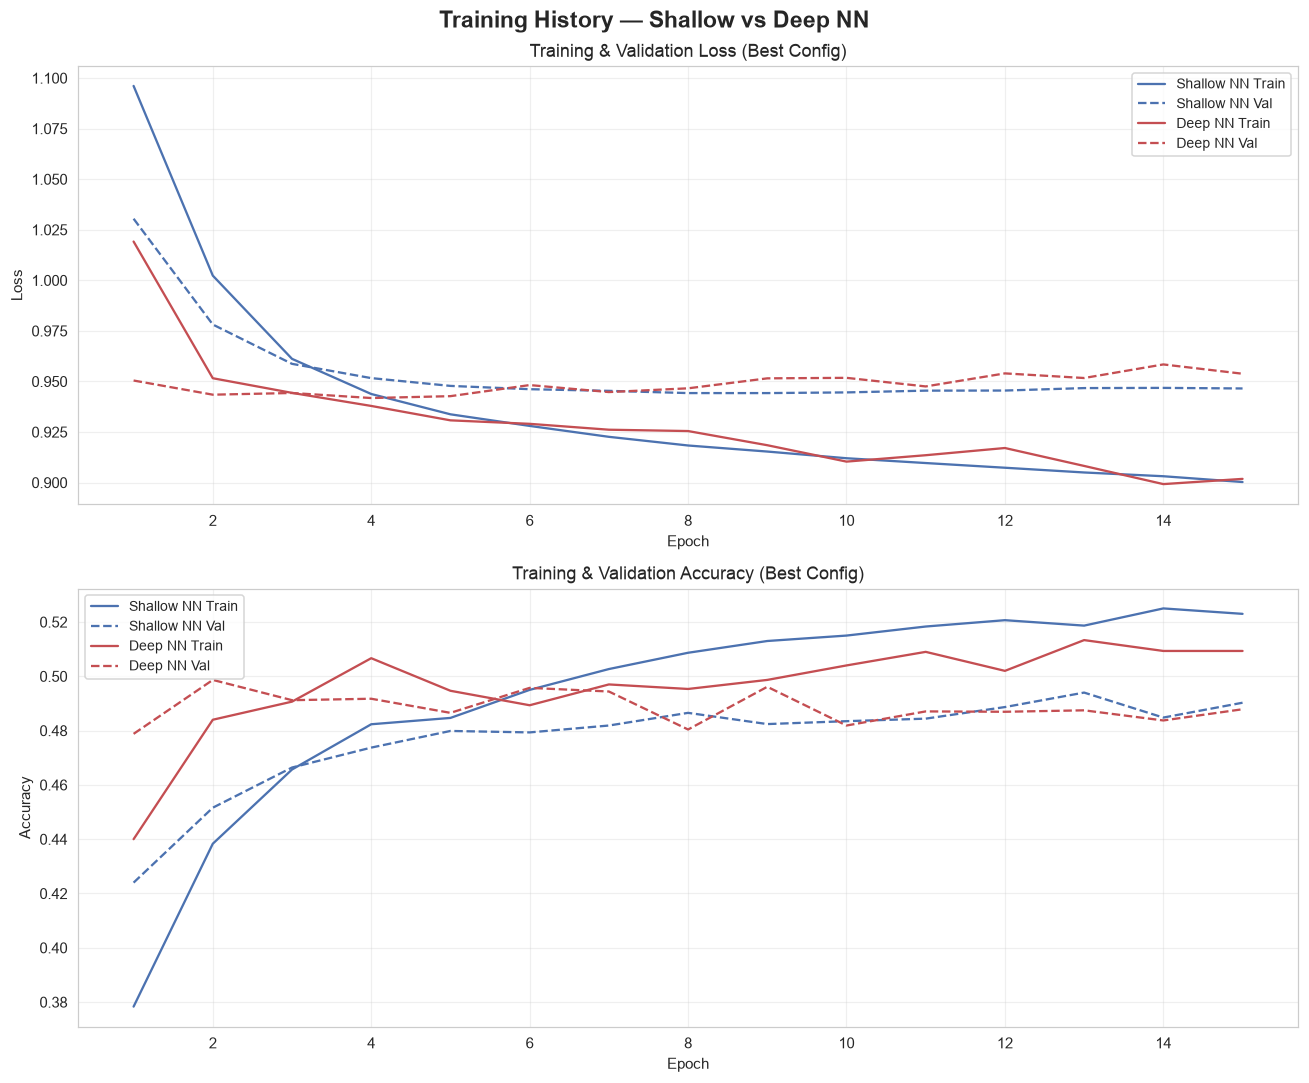

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for h, name, c in zip([shallow_history_best, deep_history_best], ['Shallow NN', 'Deep NN'], ['#4C72B0', '#C44E52']):
    ep = range(1, len(h['train_loss']) + 1)
    axes[0].plot(ep, h['train_loss'], color=c, lw=1.5, label=f'{name} Train')
    axes[0].plot(ep, h['val_loss'], color=c, lw=1.5, ls='--', label=f'{name} Val')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training & Validation Loss (Best Config)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for h, name, c in zip([shallow_history_best, deep_history_best], ['Shallow NN', 'Deep NN'], ['#4C72B0', '#C44E52']):
    ep = range(1, len(h['train_acc']) + 1)
    axes[1].plot(ep, h['train_acc'], color=c, lw=1.5, label=f'{name} Train')
    axes[1].plot(ep, h['val_acc'], color=c, lw=1.5, ls='--', label=f'{name} Val')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Training & Validation Accuracy (Best Config)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Shallow vs Deep NN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Training_History.png'), bbox_inches='tight')
plt.show()

### 8.2 Confusion Matrix (2×1)

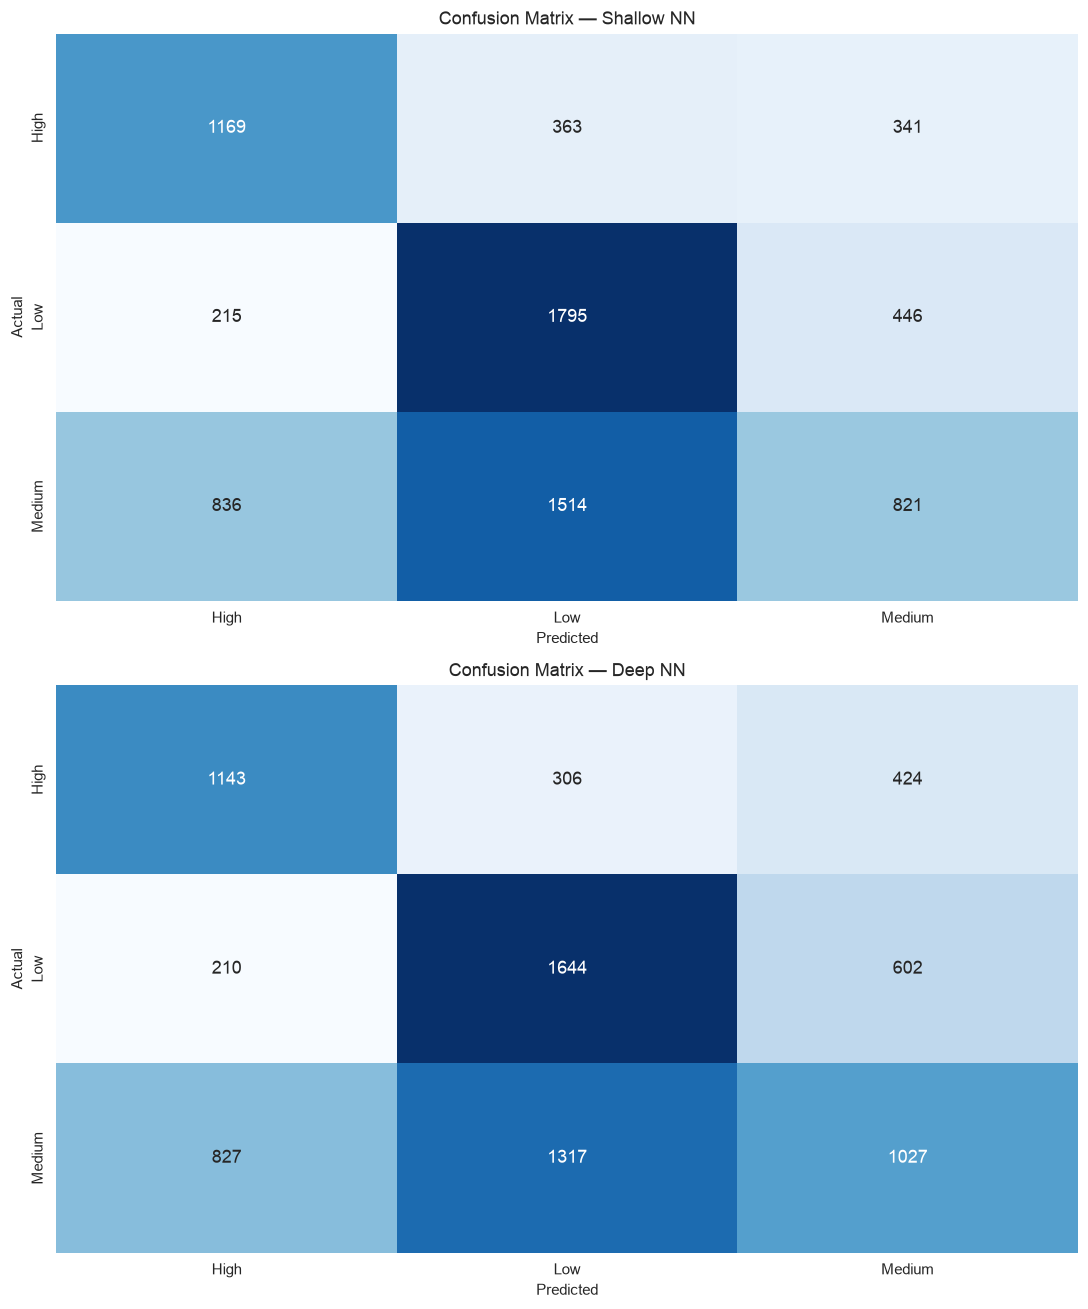

In [22]:
class_names = list(target_le.classes_)
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
for ax, m, name in zip(axes, [shallow_met, deep_met], ['Shallow NN', 'Deep NN']):
    cm = confusion_matrix(m['y_true'], m['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names, annot_kws={'size': 12})
    ax.set(xlabel='Predicted', ylabel='Actual', title=f'Confusion Matrix — {name}')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Confusion_Matrix.png'), bbox_inches='tight')
plt.show()

### 8.3 ROC Curve (2×1) with AUC — One-vs-Rest

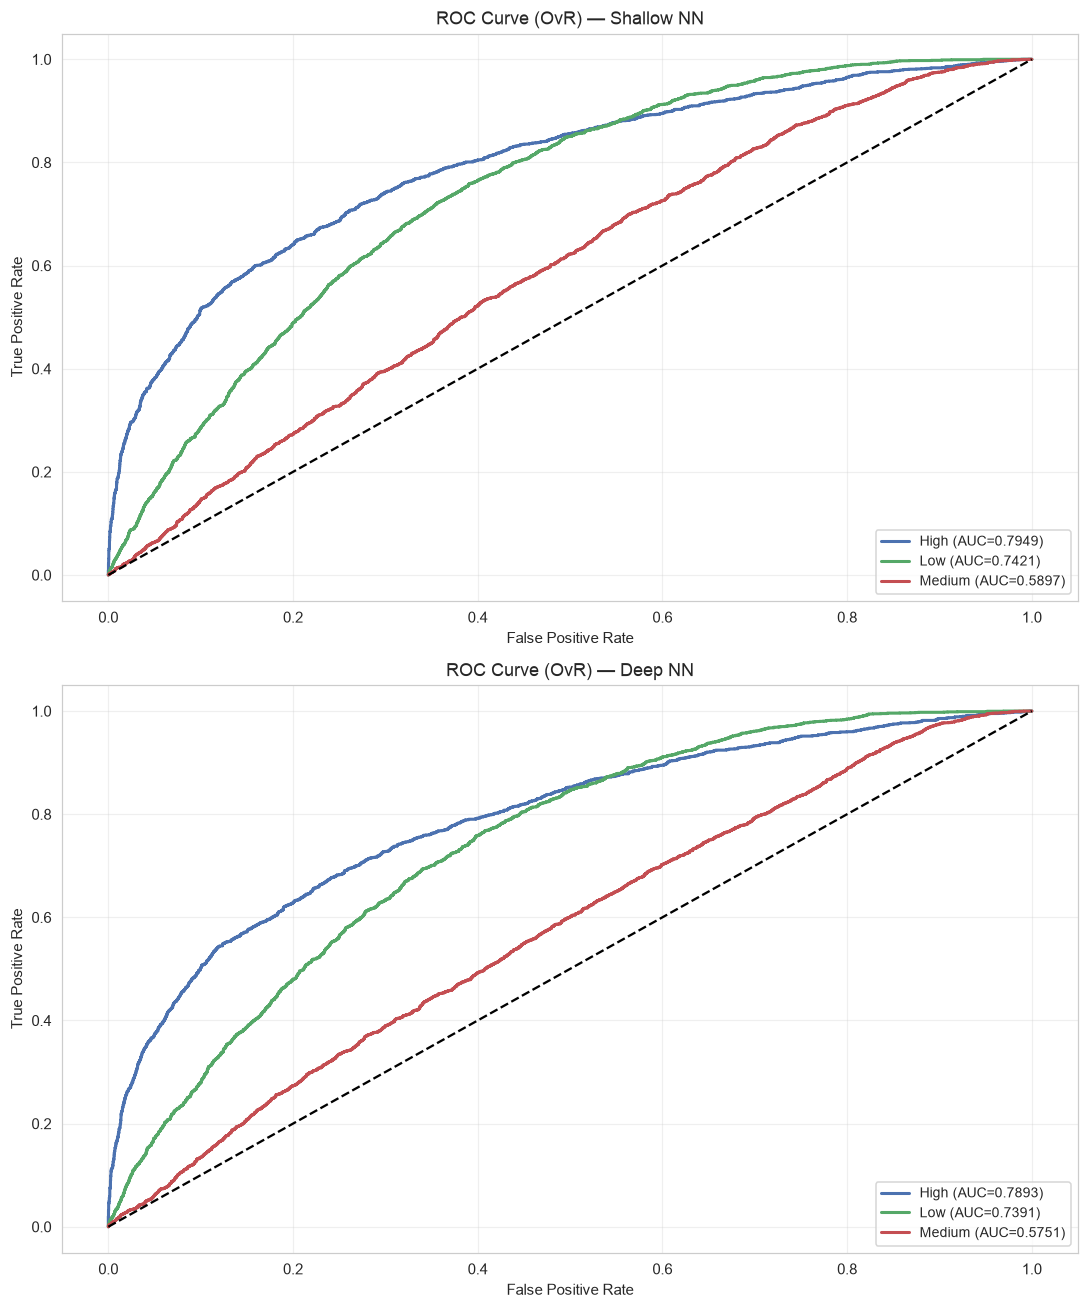

In [23]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test.values, classes=range(n_classes))

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
colors3 = ['#4C72B0', '#55A868', '#C44E52']
for ax, m, name in zip(axes, [shallow_met, deep_met], ['Shallow NN', 'Deep NN']):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], m['y_prob'][:, i])
        auc_i = roc_auc_score(y_test_bin[:, i], m['y_prob'][:, i])
        ax.plot(fpr, tpr, color=colors3[i], lw=2, label=f'{class_names[i]} (AUC={auc_i:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'ROC Curve (OvR) — {name}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'ROC_Curve.png'), bbox_inches='tight')
plt.show()

### 8.4 Evaluation Metrics — Grouped Bar Chart

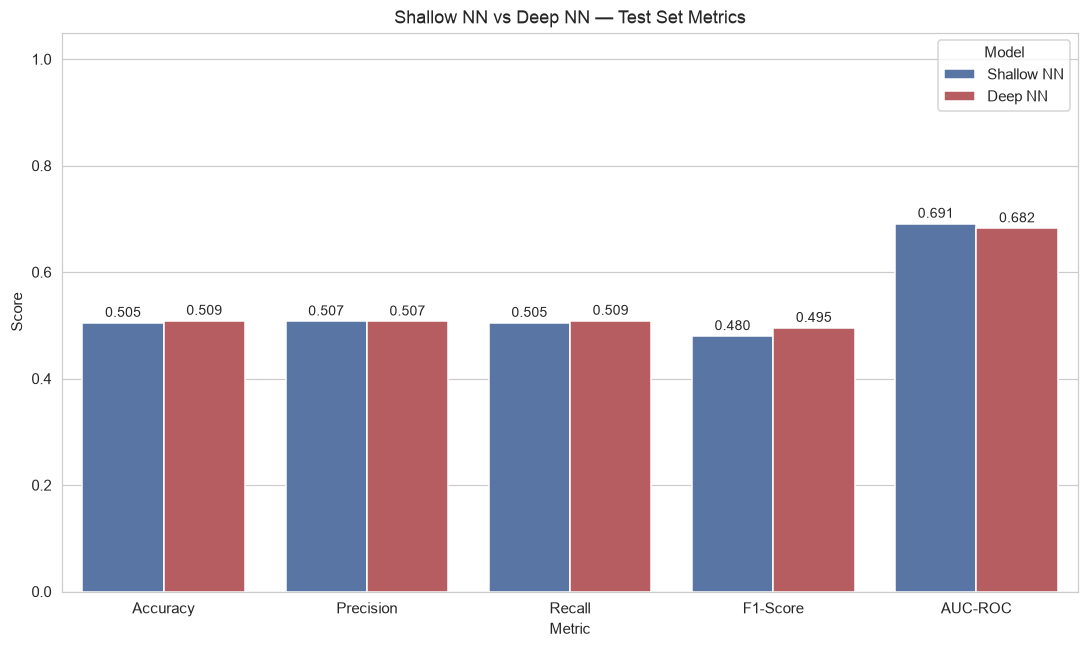

In [24]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Shallow NN': [shallow_met[k] for k in ['acc', 'prec', 'rec', 'f1', 'auc']],
    'Deep NN': [deep_met[k] for k in ['acc', 'prec', 'rec', 'f1', 'auc']]
}).melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', palette=['#4C72B0', '#C44E52'])
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Shallow NN vs Deep NN — Test Set Metrics')
for c in plt.gca().containers:
    plt.gca().bar_label(c, fmt='%.3f', fontsize=9, padding=2)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Metrics_Comparison.png'), bbox_inches='tight')
plt.show()

### 8.5 Network Structure — Layer Summary

In [25]:
def print_summary(model, name):
    print(f'\n{"="*65}')
    print(f'  {name}')
    print(f'{"="*65}')
    total = 0
    for n_, mod in model.named_modules():
        if isinstance(mod, nn.Linear):
            p = mod.in_features * mod.out_features + mod.out_features
            total += p
            print(f'  Linear({mod.in_features} -> {mod.out_features})  params={p}')
        elif isinstance(mod, nn.BatchNorm1d):
            p = 2 * mod.num_features
            total += p
            print(f'  BatchNorm1d({mod.num_features})  params={p}')
        elif isinstance(mod, nn.Dropout):
            print(f'  Dropout(p={mod.p})')
    print(f'{"="*65}')
    print(f'  Total params: {total}')
    print(f'{"="*65}\n')

print_summary(final_shallow, 'Shallow NN Architecture')
print_summary(final_deep, 'Deep NN Architecture')


  Shallow NN Architecture
  Linear(15 -> 64)  params=1024
  Linear(64 -> 3)  params=195
  Total params: 1219


  Deep NN Architecture
  Linear(15 -> 128)  params=2048
  BatchNorm1d(128)  params=256
  Dropout(p=0.3)
  Linear(128 -> 64)  params=8256
  BatchNorm1d(64)  params=128
  Dropout(p=0.3)
  Linear(64 -> 32)  params=2080
  BatchNorm1d(32)  params=64
  Dropout(p=0.3)
  Linear(32 -> 3)  params=99
  Total params: 12931



## 9. Classification Report

In [26]:
print('Shallow NN:')
print(classification_report(shallow_met['y_true'], shallow_met['y_pred'], target_names=class_names, zero_division=0))
print('Deep NN:')
print(classification_report(deep_met['y_true'], deep_met['y_pred'], target_names=class_names, zero_division=0))

Shallow NN:
              precision    recall  f1-score   support

        High       0.53      0.62      0.57      1873
         Low       0.49      0.73      0.59      2456
      Medium       0.51      0.26      0.34      3171

    accuracy                           0.50      7500
   macro avg       0.51      0.54      0.50      7500
weighted avg       0.51      0.50      0.48      7500

Deep NN:
              precision    recall  f1-score   support

        High       0.52      0.61      0.56      1873
         Low       0.50      0.67      0.57      2456
      Medium       0.50      0.32      0.39      3171

    accuracy                           0.51      7500
   macro avg       0.51      0.53      0.51      7500
weighted avg       0.51      0.51      0.50      7500



## 10. Performance Interpretation & Analysis

### Critical Analysis

* The **Shallow NN** (1 hidden layer) is simpler and trains faster. With 50,000 balanced samples,
  it may achieve competitive performance since the linear separability between Low/Medium/High
  burnout levels is partially captured by key features like anxiety, GPA, and GenAI usage.

* The **Deep NN** (3 hidden layers with Dropout, BatchNorm, L2 regularization) has greater
  capacity to model non-linear feature interactions. It is justified if it shows meaningful
  improvement in weighted F1 and AUC-ROC over the shallow baseline.

* **Weighted F1-score** and **weighted AUC-ROC (OvR)** are the most informative metrics
  for this balanced three-class problem. Accuracy alone may not capture per-class performance.

---
*Notebook by Md. Maruf (220133)*